<a href="https://colab.research.google.com/github/Sarthak196011/AI-PROJECT/blob/main/sarthak_accredian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('/content/Fraud (1).csv')

In [3]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [4]:
print("rows:", df.shape[0], "cols:", df.shape[1])
print(df['isFraud'].value_counts(normalize=True))

rows: 6362620 cols: 11
isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


In [5]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
step,6362620.0,NaN,NaN,NaN,243.397246,142.331971,1.0,156.0,239.0,335.0,743.0
type,6362620,5,CASH_OUT,2237500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amount,6362620.0,NaN,NaN,NaN,179861.903549,603858.231463,0.0,13389.57,74871.94,208721.4775,92445516.64
nameOrig,6362620,6353307,C1530544995,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceOrg,6362620.0,NaN,NaN,NaN,833883.104074,2888242.673007,0.0,0.0,14208.0,107315.175,59585040.37
newbalanceOrig,6362620.0,NaN,NaN,NaN,855113.668579,2924048.502971,0.0,0.0,0.0,144258.41,49585040.37
nameDest,6362620,2722362,C1286084959,113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldbalanceDest,6362620.0,NaN,NaN,NaN,1100701.66652,3399180.112969,0.0,0.0,132705.665,943036.7075,356015889.35
newbalanceDest,6362620.0,NaN,NaN,NaN,1224996.398202,3674128.942094,0.0,0.0,214661.44,1111909.25,356179278.92
isFraud,6362620.0,NaN,NaN,NaN,0.001291,0.035905,0.0,0.0,0.0,0.0,1.0


In [6]:
display(df.isnull().sum())

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [7]:
df.info

<bound method DataFrame.info of          step      type      amount     nameOrig  oldbalanceOrg  \
0           1   PAYMENT     9839.64  C1231006815      170136.00   
1           1   PAYMENT     1864.28  C1666544295       21249.00   
2           1  TRANSFER      181.00  C1305486145         181.00   
3           1  CASH_OUT      181.00   C840083671         181.00   
4           1   PAYMENT    11668.14  C2048537720       41554.00   
...       ...       ...         ...          ...            ...   
6362615   743  CASH_OUT   339682.13   C786484425      339682.13   
6362616   743  TRANSFER  6311409.28  C1529008245     6311409.28   
6362617   743  CASH_OUT  6311409.28  C1162922333     6311409.28   
6362618   743  TRANSFER   850002.52  C1685995037      850002.52   
6362619   743  CASH_OUT   850002.52  C1280323807      850002.52   

         newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  \
0             160296.36  M1979787155            0.00            0.00        0   
1              19384.72  M2044282225            0.00            0.00        0   
2                  0.00   C553264065            0.00            0.00        1   
3                  0.00    C38997010        21182.00            0.00        1   
4              29885.86  M1230701703            0.00            0.00        0   
...                 ...          ...             ...             ...      ...   
6362615            0.00   C776919290            0.00       339682.13        1   
6362616            0.00  C1881841831            0.00            0.00        1   
6362617            0.00  C1365125890        68488.84      6379898.11        1   
6362618            0.00  C2080388513            0.00            0.00        1   
6362619            0.00   C873221189      6510099.11      7360101.63        1   

         isFlaggedFraud  
0                     0  
1                     0  
2                     0  
3                     0  
4                     0  
...                 ...  
6362615               0  
6362616               0  
6362617               0  
6362618               0  
6362619               0  

[6362620 rows x 11 columns]>

In [8]:
fraud_percentage = df['isFraud'].value_counts(normalize=True) * 100
print("Percentage of transactions:")
print(f"Legitimate (0): {fraud_percentage[0]:.2f}%")
print(f"Fraudulent (1): {fraud_percentage[1]:.2f}%")

Percentage of transactions:
Legitimate (0): 99.87%
Fraudulent (1): 0.13%


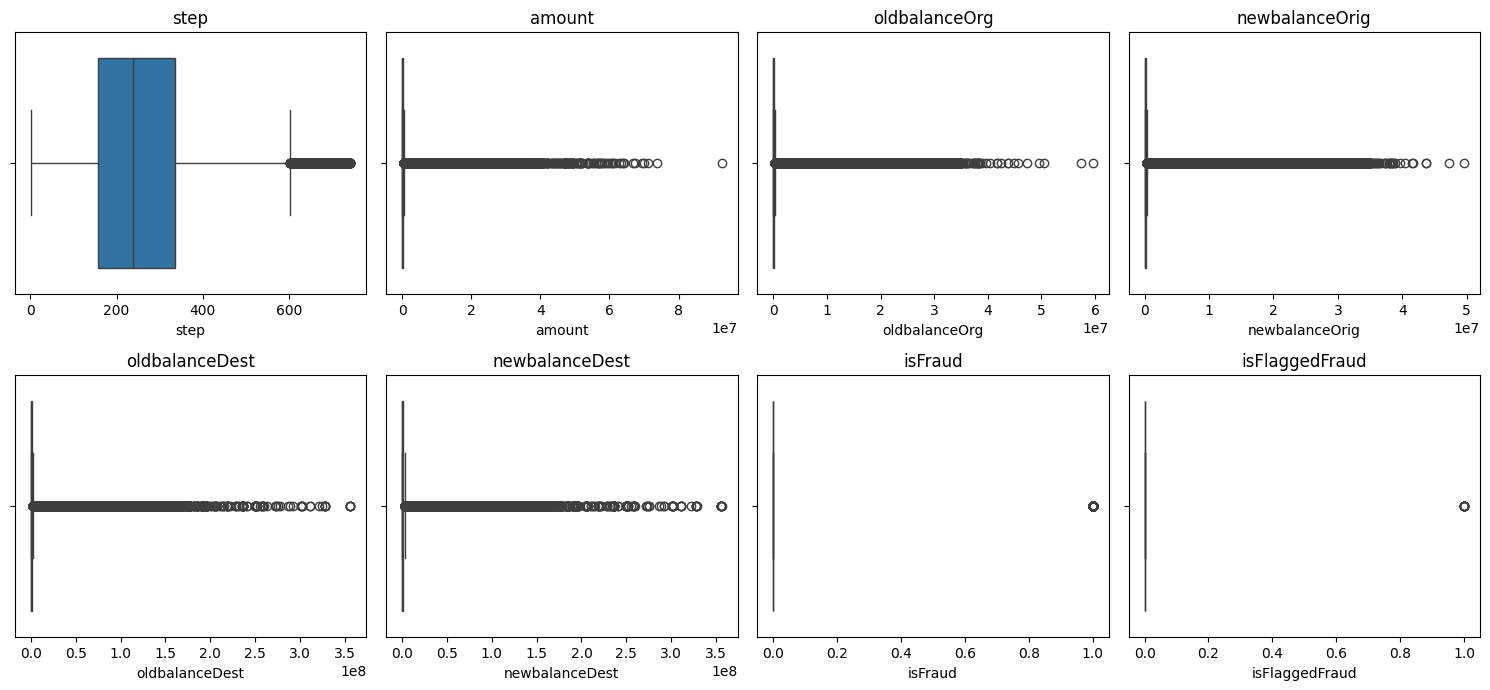

In [9]:
# Check for outliers using box plots
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()



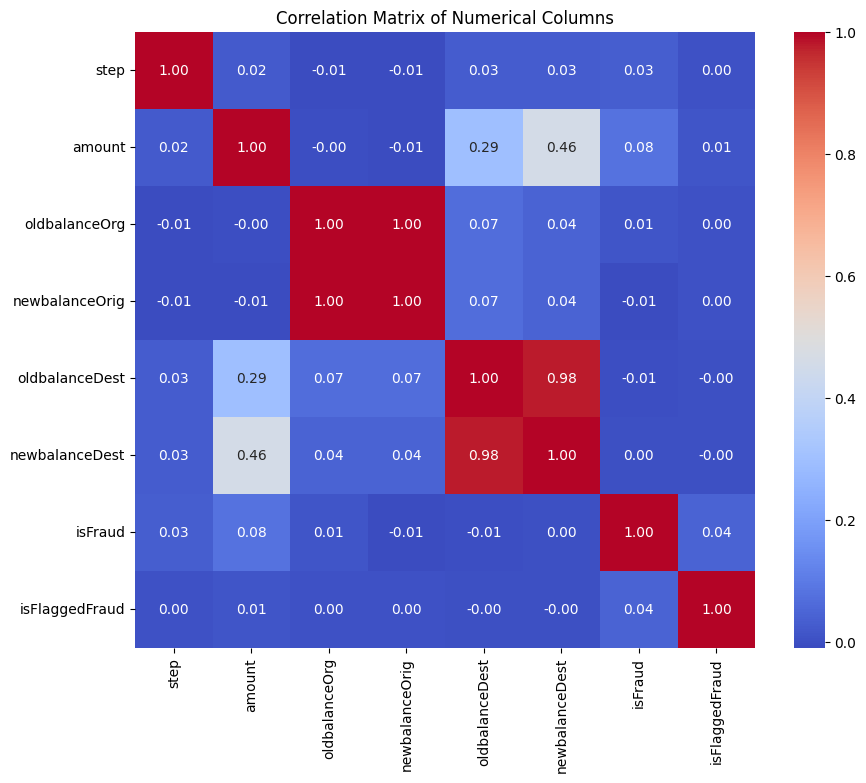

In [10]:
# Check for multicollinearity using a correlation matrix
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Columns')
plt.show()

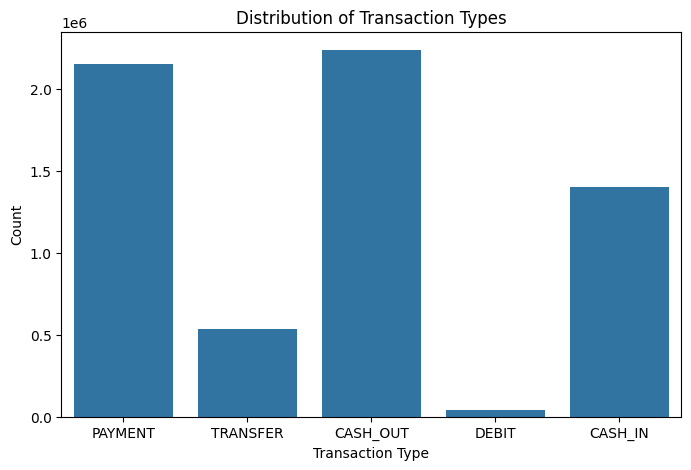

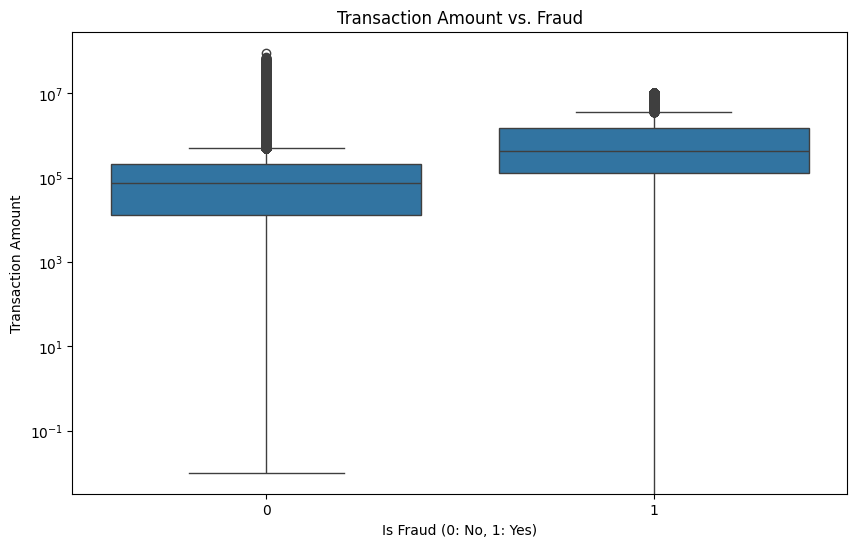

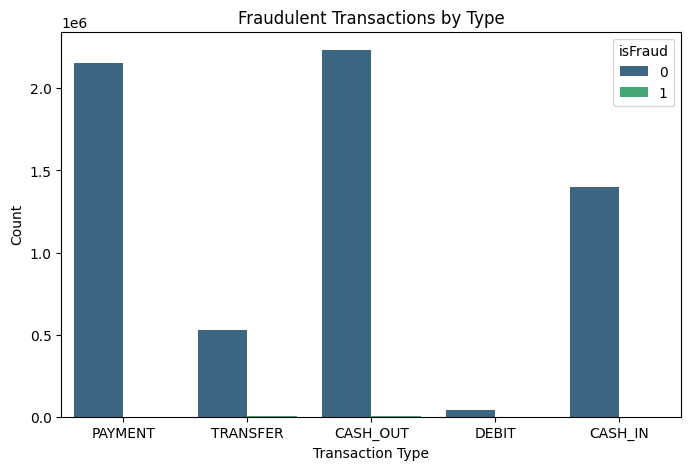

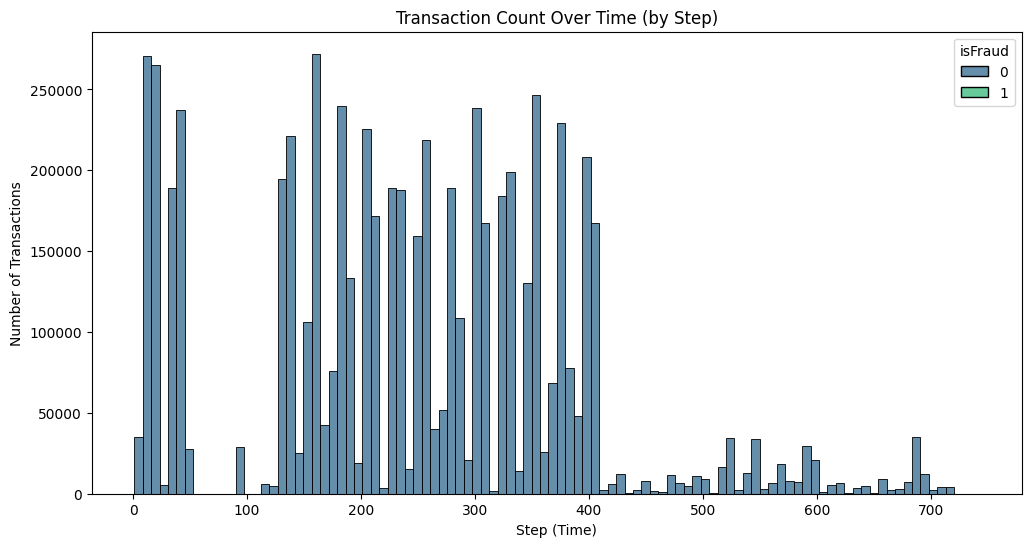

In [11]:
# Distribution of Transaction Types
plt.figure(figsize=(8, 5))
sns.countplot(x='type', data=df)
plt.title('Distribution of Transaction Types')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

# Explanation: This graph shows the frequency of each transaction type in the dataset.
# It helps understand which transaction types are most common.

# Transaction Amount vs. Fraud
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title('Transaction Amount vs. Fraud')
plt.xlabel('Is Fraud (0: No, 1: Yes)')
plt.ylabel('Transaction Amount')
plt.yscale('log')
plt.show()

# Explanation: This boxplot compares the distribution of transaction amounts for legitimate and fraudulent transactions.
# A difference in the distribution can indicate that fraudulent transactions tend to involve significantly different amounts.

# Fraudulent Transactions by Type
plt.figure(figsize=(8, 5))
sns.countplot(x='type', hue='isFraud', data=df, palette='viridis')
plt.title('Fraudulent Transactions by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.show()

# Explanation: This graph breaks down the number of fraudulent transactions by transaction type.
# It helps identify which transaction types are most commonly associated with fraud.

# Trend of Transactions over Time (using 'step' as a proxy for time)
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='step', hue='isFraud', multiple='stack', bins=100, palette='viridis')
plt.title('Transaction Count Over Time (by Step)')
plt.xlabel('Step (Time)')
plt.ylabel('Number of Transactions')
plt.show()

# Explanation: This histogram shows the number of transactions over time, separated by whether they are fraudulent or not.
# It can reveal if fraudulent activities occur more frequently at certain times.

In [12]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()
df['type_encoded'] = label_encoder.fit_transform(df['type'])
display(df[['type', 'type_encoded']].head())

,type,type_encoded
0,PAYMENT,3
1,PAYMENT,3
2,TRANSFER,4
3,CASH_OUT,1
4,PAYMENT,3


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Prepare data for the model
X = df.drop(['isFraud', 'nameOrig', 'nameDest', 'type', 'time', 'datetime'], axis=1, errors='ignore')
y = df['isFraud']

# Drop isFlaggedFraud as it has missing values and very few True values
X = X.drop('isFlaggedFraud', axis=1, errors='ignore')

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # Stratify to maintain fraud distribution

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Use class_weight to help with imbalance
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Random Forest Classifier Results:
Accuracy: 0.9996846162953835

Confusion Matrix:
 [[1906287      35]
 [    567    1897]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.98      0.77      0.86      2464

    accuracy                           1.00   1908786
   macro avg       0.99      0.88      0.93   1908786
weighted avg       1.00      1.00      1.00   1908786



In [14]:
from sklearn.metrics import classification_report

# Predict on the training set using the Random Forest model
y_pred_rf_train = rf_model.predict(X_train)

# Evaluate the Random Forest model on the training set
print("Random Forest Classifier Results on Training Data:")
print("\nClassification Report:\n", classification_report(y_train, y_pred_rf_train))
print("\nRandom Forest Classifier Results on Test Data:")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Random Forest Classifier Results on Training Data:

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   4448085
           1       1.00      1.00      1.00      5749

    accuracy                           1.00   4453834
   macro avg       1.00      1.00      1.00   4453834
weighted avg       1.00      1.00      1.00   4453834


Random Forest Classifier Results on Test Data:

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.98      0.77      0.86      2464

    accuracy                           1.00   1908786
   macro avg       0.99      0.88      0.93   1908786
weighted avg       1.00      1.00      1.00   1908786



In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Assuming X_train, X_test, y_train, and y_test are available

# Model 1: Reduced max_depth
rf_model_tuned_1 = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf_model_tuned_1.fit(X_train, y_train)
y_pred_tuned_1 = rf_model_tuned_1.predict(X_test)
print("Random Forest Model with max_depth=10:")
print(classification_report(y_test, y_pred_tuned_1))
print("-" * 30)

# Model 2: Increased min_samples_leaf
rf_model_tuned_2 = RandomForestClassifier(n_estimators=100, min_samples_leaf=5, random_state=42, class_weight='balanced')
rf_model_tuned_2.fit(X_train, y_train)
y_pred_tuned_2 = rf_model_tuned_2.predict(X_test)
print("Random Forest Model with min_samples_leaf=5:")
print(classification_report(y_test, y_pred_tuned_2))

Random Forest Model with max_depth=10:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1906322
           1       0.08      0.99      0.15      2464

    accuracy                           0.99   1908786
   macro avg       0.54      0.99      0.57   1908786
weighted avg       1.00      0.99      0.99   1908786

------------------------------
Random Forest Model with min_samples_leaf=5:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.91      0.84      0.87      2464

    accuracy                           1.00   1908786
   macro avg       0.95      0.92      0.94   1908786
weighted avg       1.00      1.00      1.00   1908786



**Questions/Answers**

1.How did you select variables to be included in the model?

ANS. We kept all numerical features and the encoded transaction type. Dropped columns like type, nameOrig, nameDest, time, datetime (identifiers/non-numeric), and isFlaggedFraud (rare positives, limited generalization).


2.What are the key factors that predict fraudulent customer?

ANS. Transaction Type: Fraud mainly occurs in CASH_OUT and TRANSFER.
Amount: Fraudulent transactions usually involve larger sums.
Balance Changes: Sudden or unusual changes in originator/destination balances are strong fraud indicators.


3.Do these factors make sense? If yes, How? If not, How not?

ANS. CASH_OUT/TRANSFER enable fund extraction.
Fraudsters prefer larger amounts.
Fraud leaves distinct balance patterns (e.g., depleted originator, inflated destination).


4.What kind of prevention should be adopted while company update its infrastructure?

ANS. Real-time monitoring & anomaly detection.
Behavioral analytics on customer patterns.
Transaction limits & velocity checks.
Multi-factor authentication for risky cases.
Rule-based filters alongside ML.
Better data collection & real-time feature generation.


5.Assuming these actions have been implemented, how would you determine if they work?

ANS. Monitor model metrics (precision, recall, AUC).
Track false positives/negatives.
Observe overall fraud rate trends.
Run A/B tests for new measures.
Use investigator feedback loops.
Do cost-benefit analysis vs. fraud loss prevented.
Check customer experience impact.